In [ ]:
import requests
from io import StringIO
import pandas as pd

# URL dari file CSV di Google Drive
data_avatar='https://docs.google.com/spreadsheets/d/e/2PACX-1vT_9BXURc7Sc3dytqbmSnh_ZqcaH_tmm7j6MqyOMV9IueFDHPAWBUm4BUhjKfHf4emZ8j5wl8npTjJE/pub?output=csv'

# Mengambil data CSV
response = requests.get(data_avatar)

# Memeriksa apakah permintaan berhasil
if response.status_code == 200:
    # Mengonversi konten respons menjadi string
    csv_data = response.content.decode('utf-8')

    # Membuat objek StringIO untuk mensimulasikan objek mirip file
    csv_file = StringIO(csv_data)

    # Inisialisasi daftar kosong untuk menyimpan baris yang menyebabkan kesalahan parsing
    error_lines = []

    # Membaca CSV sambil mengabaikan baris yang menyebabkan kesalahan parsing
    full_df = pd.read_csv(csv_file, error_bad_lines=False)

    # Menampilkan DataFrame
    print(full_df)
else:
    print("Gagal mengambil data CSV")


TypeError: read_csv() got an unexpected keyword argument 'error_bad_lines'

In [ ]:
df = full_df[["text_combined"]]

df.head()


,text_combined
0,opinion two topics one enjoy watching kung fu ...
1,finished season frieren beyond journey end mov...
2,today played stardew valley hours finished rew...
3,avatar last airbender
4,rewatched avatar last airbender kid avid katar...


In [ ]:
!pip install tweet-preprocessor
!pip install textblob
!pip install wordcloud
!pip install nltk

In [ ]:
import preprocessor as p
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import wordpunct_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:

data_tweet = list(df['text_combined'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity

    if analysis.sentiment.polarity > 0.0:
        total_positif += 1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')
    total += 1

print(f'Hasil analisis data:\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}')
print(f'\nTotal Data : {total}')

Hasil analisis data:
Positif = 664
Netral = 517
Negatif = 172

Total Data : 1353


In [ ]:
df['klasifikasi']=status
df

,text_combined,klasifikasi
0,opinion two topics one enjoy watching kung fu ...,Positif
1,finished season frieren beyond journey end mov...,Positif
2,today played stardew valley hours finished rew...,Netral
3,avatar last airbender,Netral
4,rewatched avatar last airbender kid avid katar...,Positif
...,...,...
1348,avatar last airbender book earth warra finale ...,Positif
1349,avatar last airbender original series rewatche...,Positif
1350,damsel gentlemen avatar last airbender,Netral
1351,might time rewatch avatar last airbender love ...,Positif


In [ ]:
df

,text_combined,klasifikasi
0,opinion two topics one enjoy watching kung fu ...,Positif
1,finished season frieren beyond journey end mov...,Positif
2,today played stardew valley hours finished rew...,Netral
3,avatar last airbender,Netral
4,rewatched avatar last airbender kid avid katar...,Positif
...,...,...
1348,avatar last airbender book earth warra finale ...,Positif
1349,avatar last airbender original series rewatche...,Positif
1350,damsel gentlemen avatar last airbender,Netral
1351,might time rewatch avatar last airbender love ...,Positif


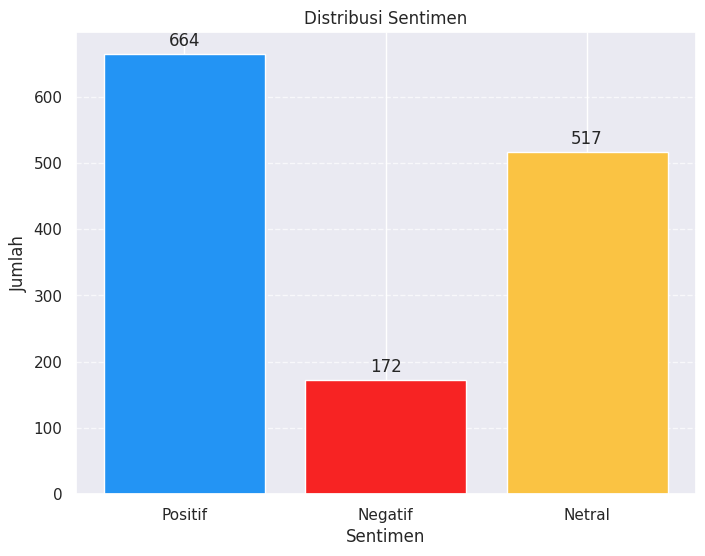

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
labels = ['Positif', 'Negatif', 'Netral']
counts = [total_positif, total_negatif, total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f4', '#f72323', '#fac343'])

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, height),
                                    xytext=(0,3),
                                    textcoords="offset points",
                                    ha='center', va='bottom')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    ax.set_xlabel('Sentimen')
    ax.set_ylabel('Jumlah')
    ax.set_title(title)

    plt.show()

show_bar_chart(labels, counts, "Distribusi Sentimen")


In [ ]:
dataset = [tuple(x) for x in df.to_records(index=False)]


In [ ]:
import random

set_positif = []
set_negatif = []
set_netral = []

for n in dataset:
    if n[1] == 'Positif':
        set_positif.append(n)
    elif n[1] == 'Negatif':
        set_negatif.append(n)
    else:
        set_netral.append(n)

set_positif = random.sample(set_positif, k=int(len(set_positif)/2))
set_negatif = random.sample(set_negatif, k=int(len(set_negatif)/2))
set_netral = random.sample(set_netral, k=int(len(set_netral)/2))

train = set_positif + set_negatif + set_netral

train_set = []
for n in train:
    train_set.append(n)


In [ ]:
df

,text_combined,klasifikasi
0,opinion two topics one enjoy watching kung fu ...,Positif
1,finished season frieren beyond journey end mov...,Positif
2,today played stardew valley hours finished rew...,Netral
3,avatar last airbender,Netral
4,rewatched avatar last airbender kid avid katar...,Positif
...,...,...
1348,avatar last airbender book earth warra finale ...,Positif
1349,avatar last airbender original series rewatche...,Positif
1350,damsel gentlemen avatar last airbender,Netral
1351,might time rewatch avatar last airbender love ...,Positif


In [ ]:
import nltk
from nltk.classify import NaiveBayesClassifier
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentAnalyzer
from nltk.sentiment.util import *



In [ ]:
from textblob.classifiers import NaiveBayesClassifier
cl = NaiveBayesClassifier(train_set)
print("akurasi test: ", cl.accuracy(dataset))

akurasi test:  0.7797487065779749


In [ ]:
train_set

[('honestly avatar last airbender korra become trending years later theyre good shows understand',
  'Positif'),
 ('cant tell yall much im enjoying rewatching avatar last airbender since live action',
  'Positif'),
 ('put give series post favorite character got avatar last airbender sokka zuko two would aang toph',
  'Positif'),
 ('watch avatar last airbender see many fights many people aang beats hes anything pacifist might say really isnt remember one earth kingdom general captured katara release aangs avatar state peaceful',
  'Positif'),
 ('watching avatar last airbender siege north parts day snows heat completely immersive experience',
  'Positif'),
 ('finished avatar last airbender first time ever honestly say without doubt heart one greatest shows animated ever created',
  'Positif'),
 ('finally finished avatar last airbender got ta say really enjoyed loved characters toph time favorite followed closely zuko iroh',
  'Positif'),
 ('dont know youve ever watch avatar last airbende

In [ ]:
data_tweet = list(df['text_combined'])
polaritas = 0

status = []
total_positif= total_negatif= total_netral= total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet, classifier=cl)


    if analysis.classify() == 'Positif':
        total_positif += 1
    elif analysis.classify() == 'Netral':
        total_netral += 1
    else:
        total_negatif += 1

    status.append(analysis.classify())
    total += 1

print(f'Hasil analisis data:\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif= {total_negatif}')
print(f'\nTotal Data : {total}')


Hasil analisis data:
Positif = 606
Netral = 698
Negatif= 49

Total Data : 1353


In [ ]:
status = pd.DataFrame({"klasifikasi Bayes": status})
df['klasifikasi_bayes']=status

In [ ]:
df

,text_combined,klasifikasi,klasifikasi_bayes
0,opinion two topics one enjoy watching kung fu ...,Positif,Positif
1,finished season frieren beyond journey end mov...,Positif,Positif
2,today played stardew valley hours finished rew...,Netral,Netral
3,avatar last airbender,Netral,Netral
4,rewatched avatar last airbender kid avid katar...,Positif,Positif
...,...,...,...
1348,avatar last airbender book earth warra finale ...,Positif,Positif
1349,avatar last airbender original series rewatche...,Positif,Positif
1350,damsel gentlemen avatar last airbender,Netral,Netral
1351,might time rewatch avatar last airbender love ...,Positif,Positif


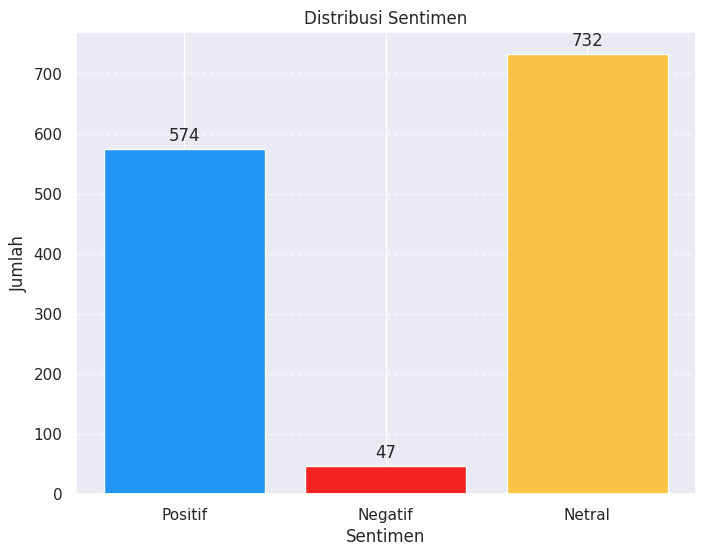

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
labels = ['Positif', 'Negatif', 'Netral']
counts = [total_positif, total_negatif, total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f4', '#f72323', '#fac343'])

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, height),
                                    xytext=(0,3),
                                    textcoords="offset points",
                                    ha='center', va='bottom')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    ax.set_xlabel('Sentimen')
    ax.set_ylabel('Jumlah')
    ax.set_title(title)

    plt.show()

show_bar_chart(labels, counts, "Distribusi Sentimen")
